In [1]:
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Reset to inline backend for notebooks
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from qiskit_aer import AerSimulator

# Load Backend
backend = FakeBrisbane()
coupling_map = backend.coupling_map
print(f"Loaded backend: {backend.name} with {backend.num_qubits} qubits")

Loaded backend: fake_brisbane with 127 qubits


## 1. Verify Topology & Connectivity

Before building the circuit, we must verify:
- **Source cluster (58, 71, 77)**: Is qubit 71 connected to both 58 and 77?
- **Destination cluster (81, 72, 62)**: Is qubit 72 connected to both 81 and 62?
- **Syndrome ancillas (82, 63)**: 
  - Ancilla 82 → needs to access qubits 81 and 72 for $Z_{81}Z_{72}$ parity
  - Ancilla 63 → needs to access qubits 72 and 62 for $Z_{72}Z_{62}$ parity

In [2]:
# Define Qubit Roles
# Source: 58 - 71 - 77 (data at 71, ancillas at 58 and 77)
# Destination: 81 - 72 - 62 (data arrives at 72)
# Syndrome Ancillas: 82 (for top pair 81-72), 63 (for bottom pair 72-62)

source_qubits = [58, 71, 77]  # [top, data, bottom]
dest_qubits = [81, 72, 62]    # [top', data', bottom']
ancilla_qubits = [82, 63]     # Syndrome measurement ancillas [top_ancilla, bottom_ancilla]
travel_path = [78,79,80]

# Extract individual qubits for clarity
src_top, src_data, src_bot = source_qubits
dst_top, dst_data, dst_bot = dest_qubits
anc_top, anc_bot = ancilla_qubits

def check_connection(u, v):
    """Returns True if physical wire exists between u and v."""
    return u in coupling_map.neighbors(v) or v in coupling_map.neighbors(u)

print(f"=== Checking Topology on {backend.name} ===\n")

# A. Source Check - Data qubit must connect to encoding ancillas
valid_src_1 = check_connection(src_data, src_top)
valid_src_2 = check_connection(src_data, src_bot)
print(f"SOURCE ({src_top} - {src_data} - {src_bot}):")
print(f"  {src_data}-{src_top} connected? {valid_src_1}")
print(f"  {src_data}-{src_bot} connected? {valid_src_2}")
if valid_src_1 and valid_src_2:
    print("  ✓ Source cluster is VALID")
else:
    print("  ⚠️ Source cluster has connectivity issues!")

# B. Destination Check - Center qubit must connect to neighbors
valid_dst_1 = check_connection(dst_data, dst_top)
valid_dst_2 = check_connection(dst_data, dst_bot)
print(f"\nDESTINATION ({dst_top} - {dst_data} - {dst_bot}):")
print(f"  {dst_data}-{dst_top} connected? {valid_dst_1}")
print(f"  {dst_data}-{dst_bot} connected? {valid_dst_2}")
if valid_dst_1 and valid_dst_2:
    print("  ✓ Destination cluster is VALID")
else:
    print("  ⚠️ Destination cluster has connectivity issues!")

# C. Syndrome Ancilla Check (Critical!)
# Top ancilla needs to reach BOTH dst_top and dst_data for Z parity
# Bottom ancilla needs to reach BOTH dst_data and dst_bot for Z parity
s1_check_anc_top = check_connection(anc_top, dst_top)
s1_check_anc_data = check_connection(anc_top, dst_data)
s2_check_anc_data = check_connection(anc_bot, dst_data)
s2_check_anc_bot = check_connection(anc_bot, dst_bot)

print(f"\nSYNDROME ANCILLAS:")
print(f"  Ancilla {anc_top} (for Z_{dst_top}Z_{dst_data}):")
print(f"    {anc_top}-{dst_top} connected? {s1_check_anc_top}")
print(f"    {anc_top}-{dst_data} connected? {s1_check_anc_data}")
print(f"    → Direct syndrome? {s1_check_anc_top and s1_check_anc_data}")

print(f"  Ancilla {anc_bot} (for Z_{dst_data}Z_{dst_bot}):")
print(f"    {anc_bot}-{dst_data} connected? {s2_check_anc_data}")
print(f"    {anc_bot}-{dst_bot} connected? {s2_check_anc_bot}")
print(f"    → Direct syndrome? {s2_check_anc_data and s2_check_anc_bot}")

# Summary
print("\n=== CONNECTIVITY SUMMARY ===")
if not (s1_check_anc_top and s1_check_anc_data):
    print(f"  ⚠️ Ancilla {anc_top} cannot directly measure Z_{dst_top}Z_{dst_data} → Need SWAP-assisted syndrome")
if not (s2_check_anc_data and s2_check_anc_bot):
    print(f"  ⚠️ Ancilla {anc_bot} cannot directly measure Z_{dst_data}Z_{dst_bot} → Need SWAP-assisted syndrome")

=== Checking Topology on fake_brisbane ===

SOURCE (58 - 71 - 77):
  71-58 connected? True
  71-77 connected? True
  ✓ Source cluster is VALID

DESTINATION (81 - 72 - 62):
  72-81 connected? True
  72-62 connected? True
  ✓ Destination cluster is VALID

SYNDROME ANCILLAS:
  Ancilla 82 (for Z_81Z_72):
    82-81 connected? True
    82-72 connected? False
    → Direct syndrome? False
  Ancilla 63 (for Z_72Z_62):
    63-72 connected? False
    63-62 connected? True
    → Direct syndrome? False

=== CONNECTIVITY SUMMARY ===
  ⚠️ Ancilla 82 cannot directly measure Z_81Z_72 → Need SWAP-assisted syndrome
  ⚠️ Ancilla 63 cannot directly measure Z_72Z_62 → Need SWAP-assisted syndrome


## 2. Visualize the Layout

Let's visualize the source, destination, and transport paths on the chip topology.

Verifying edge orientations...
✓ All edges are horizontal or vertical!


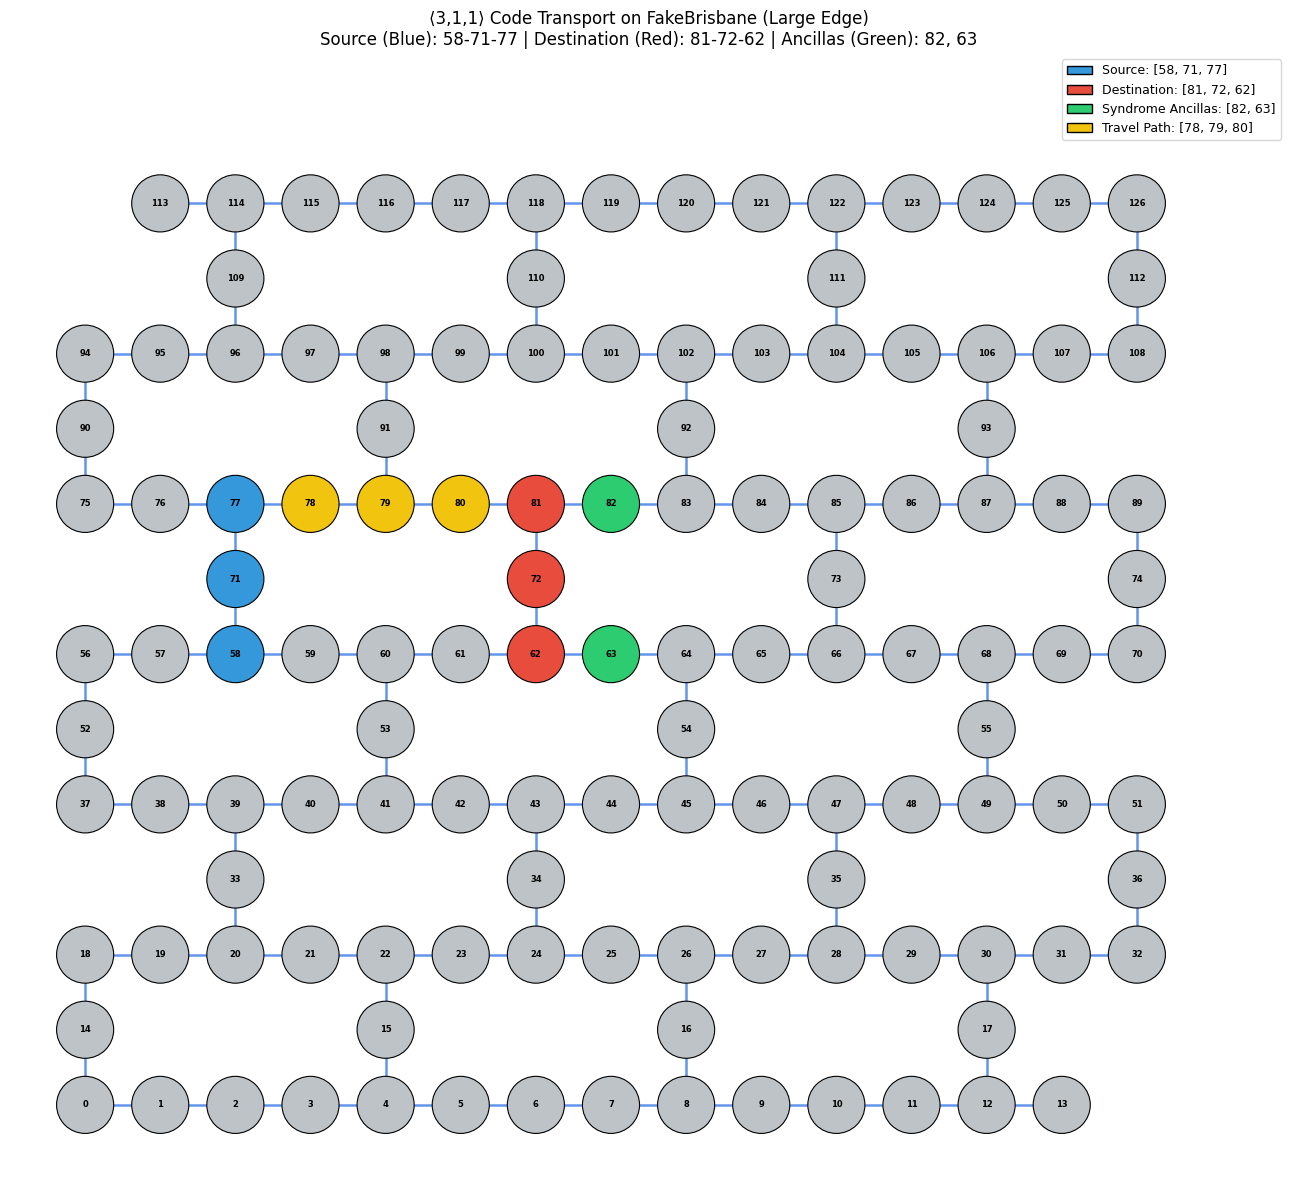


=== Transport Paths (Large Edge - 18 SWAPs total) ===
  77 → 62: SWAP(77,78) → SWAP(78,79) → SWAP(79,80) → SWAP(80,81) → SWAP(81,72) → SWAP(72,62)
  71 → 72: SWAP(71,77) → SWAP(77,78) → SWAP(78,79) → SWAP(79,80) → SWAP(80,81) → SWAP(81,72)
  58 → 81: SWAP(58,71) → SWAP(71,77) → SWAP(77,78) → SWAP(78,79) → SWAP(79,80) → SWAP(80,81)


In [3]:
# Build custom Heavy Hex visualization with positions derived from actual connectivity
# Key insight: Flag qubits connect vertically to specific main-row qubits
from matplotlib.patches import Patch

edges = list(coupling_map.get_edges())

# Build adjacency
adj = {i: set() for i in range(127)}
for e in edges:
    adj[e[0]].add(e[1])
    adj[e[1]].add(e[0])

# Looking at neighbor analysis:
# Flag 14 connects 0-18, Flag 15 connects 4-22, Flag 16 connects 8-26, Flag 17 connects 12-30
# Flag 33 connects 20-39, Flag 34 connects 24-43, Flag 35 connects 28-47, Flag 36 connects 32-51
# etc.

# For Heavy Hex: main rows are horizontal, flag qubits connect vertically
# Position main rows with integer x coords, flags at same x as their connections

pos = {}

# Row 0 (y=0): qubits 0-13  
# x positions: 0,1,2,3,4,5,6,7,8,9,10,11,12,13
for i, q in enumerate([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]):
    pos[q] = (i, 0)

# Flag row 1 (y=1): 14,15,16,17 connect to qubits in rows 0 and 2
# 14: 0,18 → x=0; 15: 4,22 → x=4; 16: 8,26 → x=8; 17: 12,30 → x=12
pos[14] = (0, 1)
pos[15] = (4, 1)
pos[16] = (8, 1)
pos[17] = (12, 1)

# Row 2 (y=2): qubits 18-32 - need to place so 18 is at x=0, 22 at x=4, 26 at x=8, 30 at x=12
# 18,19,20,21,22,23,24,25,26,27,28,29,30,31,32
# If 18 at x=0 and 22 at x=4, spacing = 1 per qubit
for i, q in enumerate([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]):
    pos[q] = (i, 2)

# Flag row 3 (y=3): 33,34,35,36
# 33: 20,39 → x=2 (20 is at x=2); 34: 24,43 → x=6; 35: 28,47 → x=10; 36: 32,51 → x=14
pos[33] = (2, 3)
pos[34] = (6, 3)
pos[35] = (10, 3)
pos[36] = (14, 3)

# Row 4 (y=4): 37-51 - place so 39 is at x=2, 43 at x=6, 47 at x=10, 51 at x=14
# 37,38,39,40,41,42,43,44,45,46,47,48,49,50,51
# 39 at index 2 should be at x=2, so 37 at x=0
for i, q in enumerate([37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]):
    pos[q] = (i, 4)

# Flag row 5 (y=5): 52,53,54,55
# 52: 37,56 → x=0 (37 is at x=0); 53: 41,60 → x=4 (41 is at x=4); 54: 45,64 → x=8; 55: 49,68 → x=12
pos[52] = (0, 5)
pos[53] = (4, 5)
pos[54] = (8, 5)
pos[55] = (12, 5)

# Row 6 (y=6): 56-70 - place so 56 at x=0, 60 at x=4, 64 at x=8, 68 at x=12
for i, q in enumerate([56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70]):
    pos[q] = (i, 6)

# Flag row 7 (y=7): 71,72,73,74
# 71: 58,77 → x=2 (58 is at x=2); 72: 62,81 → x=6; 73: 66,85 → x=10; 74: 70,89 → x=14
pos[71] = (2, 7)
pos[72] = (6, 7)
pos[73] = (10, 7)
pos[74] = (14, 7)

# Row 8 (y=8): 75-89 - place so 77 at x=2, 81 at x=6, 85 at x=10, 89 at x=14
for i, q in enumerate([75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]):
    pos[q] = (i, 8)

# Flag row 9 (y=9): 90,91,92,93
# 90: 75,94 → x=0; 91: 79,98 → x=4; 92: 83,102 → x=8; 93: 87,106 → x=12
pos[90] = (0, 9)
pos[91] = (4, 9)
pos[92] = (8, 9)
pos[93] = (12, 9)

# Row 10 (y=10): 94-108
for i, q in enumerate([94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108]):
    pos[q] = (i, 10)

# Flag row 11 (y=11): 109,110,111,112
# 109: 96,114 → 96 is at x=2, 114 is at x=1 (in row 12) - DIAGONAL!
# 110: 100,118 → 100 is at x=6, need 118 at x=6
# 111: 104,122 → 104 is at x=10, need 122 at x=10
# 112: 108,126 → 108 is at x=14, need 126 at x=14
# These connect diagonally in IBM's layout! Let's place flag at the upper qubit's x
pos[109] = (2, 11)
pos[110] = (6, 11)
pos[111] = (10, 11)
pos[112] = (14, 11)

# Row 12 (y=12): 113-126 - place so 114 at x=2 to connect to 109 vertically
# Need: 114 at x=2, 118 at x=6, 122 at x=10, 126 at x=14
# 113,114,115,116,117,118,119,120,121,122,123,124,125,126 (14 qubits)
# If 114 is at index 1 and should be at x=2, then 113 at x=1
# Actually let's check: 114-113 are connected horizontally, 114-109 vertically
# So 113 at x=1, 114 at x=2, ..., 126 at x=14
for i, q in enumerate([113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]):
    pos[q] = (i + 1, 12)  # Shift by 1 so 114 (index 1) is at x=2

# Verify all edges
print("Verifying edge orientations...")
diagonal_edges = []
for e in edges:
    q0, q1 = e[0], e[1]
    if q0 in pos and q1 in pos:
        x0, y0 = pos[q0]
        x1, y1 = pos[q1]
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        if dx > 0.01 and dy > 0.01:
            diagonal_edges.append((q0, q1, pos[q0], pos[q1]))

if diagonal_edges:
    print(f"⚠️ Found {len(diagonal_edges)} diagonal edges:")
    for q0, q1, p0, p1 in diagonal_edges:
        print(f"  Edge {q0}-{q1}: {p0} → {p1}")
else:
    print("✓ All edges are horizontal or vertical!")

# Color nodes by role
node_colors = {}
for i in range(backend.num_qubits):
    if i in source_qubits: 
        node_colors[i] = '#3498db'  # Blue (Source)
    elif i in dest_qubits: 
        node_colors[i] = '#e74c3c'  # Red (Destination)
    elif i in ancilla_qubits:
        node_colors[i] = '#2ecc71'  # Green (Syndrome Ancillas)
    elif i in travel_path:
        node_colors[i] = '#f1c40f'  # Yellow (Travel Path)  
    else: 
        node_colors[i] = '#bdc3c7'  # Light Gray

# Create figure
fig, ax = plt.subplots(figsize=(18, 12))

# Draw edges
for edge in edges:
    q0, q1 = edge[0], edge[1]
    if q0 in pos and q1 in pos:
        x0, y0 = pos[q0]
        x1, y1 = pos[q1]
        ax.plot([x0, x1], [y0, y1], 'cornflowerblue', linewidth=1.8, zorder=1)

# Draw nodes
node_radius = 0.38
for i in range(backend.num_qubits):
    if i in pos:
        x, y = pos[i]
        circle = plt.Circle((x, y), node_radius, color=node_colors[i], ec='black', linewidth=0.8, zorder=2)
        ax.add_patch(circle)
        ax.text(x, y, str(i), ha='center', va='center', fontsize=6, fontweight='bold', zorder=3)

ax.set_xlim(-1, 16)
ax.set_ylim(-1, 14)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("⟨3,1,1⟩ Code Transport on FakeBrisbane (Large Edge)\nSource (Blue): 58-71-77 | Destination (Red): 81-72-62 | Ancillas (Green): 82, 63", fontsize=12)

legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label=f'Source: {source_qubits}'),
    Patch(facecolor='#e74c3c', edgecolor='black', label=f'Destination: {dest_qubits}'),
    Patch(facecolor='#2ecc71', edgecolor='black', label=f'Syndrome Ancillas: {ancilla_qubits}'),
    Patch(facecolor='#f1c40f', edgecolor='black', label=f'Travel Path: {travel_path}'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Show the transport paths
print("\n=== Transport Paths (Large Edge - 18 SWAPs total) ===")
print("  77 → 62: SWAP(77,78) → SWAP(78,79) → SWAP(79,80) → SWAP(80,81) → SWAP(81,72) → SWAP(72,62)")
print("  71 → 72: SWAP(71,77) → SWAP(77,78) → SWAP(78,79) → SWAP(79,80) → SWAP(80,81) → SWAP(81,72)")
print("  58 → 81: SWAP(58,71) → SWAP(71,77) → SWAP(77,78) → SWAP(78,79) → SWAP(79,80) → SWAP(80,81)")

## 3. Build the Quantum Circuit

The circuit has 3 stages for the **Large Edge** transport path:

1. **Encoding** (at source 58-71-77): 
   - Prepare $|+\rangle$ on data qubit 71
   - CNOT to 58 and 77 → creates $|+\rangle_L = (|000\rangle + |111\rangle)/\sqrt{2}$

2. **Transport** (SWAP chains along row 8 via qubits 78-79-80): 
   - Move 77 → 62 (6 SWAPs) - bottom qubit
   - Move 71 → 72 (6 SWAPs) - data qubit  
   - Move 58 → 81 (6 SWAPs) - top qubit
   - **Total: 18 SWAPs** (vs 12 in SmallEdge)

3. **SWAP-Assisted Syndrome Measurement**:
   - Since ancillas don't directly connect to all data qubits, use **SWAP-CNOT-SWAP** pattern
   - Syndrome 1: CNOT(81→82), SWAP(72↔81), CNOT(81→82), SWAP back
   - Syndrome 2: CNOT(62→63), SWAP(62↔72), CNOT(62→63), SWAP back

In [4]:
# Create Circuit - 2 classical bits for syndrome measurement
qc = QuantumCircuit(backend.num_qubits, 2)

# ============================================================
# STEP 1: ENCODING (at Source: 58, 71, 77)
# ============================================================
# Data qubit is 71, encoding ancillas are 58 and 77
# Prepare |+⟩ on data qubit
qc.h(71)

# Encode into [[3,1,1]] repetition code (GHZ-like state)
# |+⟩ = (|0⟩ + |1⟩)/√2  -->  (|000⟩ + |111⟩)/√2
if valid_src_1: 
    qc.cx(71, 58)  # CNOT from data to top ancilla
if valid_src_2: 
    qc.cx(71, 77)  # CNOT from data to bottom ancilla
qc.barrier(label="Encoding Complete")

print("Step 1: Encoding complete (at source 58-71-77)")
print("  - H(71) creates |+⟩")
print("  - CNOT(71→58) and CNOT(71→77) spread the state")
print("  - Logical state: (|000⟩ + |111⟩)/√2")

Step 1: Encoding complete (at source 58-71-77)
  - H(71) creates |+⟩
  - CNOT(71→58) and CNOT(71→77) spread the state
  - Logical state: (|000⟩ + |111⟩)/√2


In [5]:
# ============================================================
# STEP 2: TRANSPORT (SWAP Chains) - Large Edge Path
# ============================================================
# Move the encoded packet from source to destination:
#   77 → 62 (bottom qubit)
#   71 → 72 (data qubit)
#   58 → 81 (top qubit)

print("\nStep 2: Transport via SWAP chains (Large Edge - 18 SWAPs)")

# --- Move 77 → 62 (6 SWAPs) ---
print("\n  Moving bottom qubit 77 → 62:")
qc.swap(77, 78); print("    SWAP(77, 78)")
qc.swap(78, 79); print("    SWAP(78, 79)")
qc.swap(79, 80); print("    SWAP(79, 80)")
qc.swap(80, 81); print("    SWAP(80, 81)")
qc.swap(81, 72); print("    SWAP(81, 72)")
qc.swap(72, 62); print("    SWAP(72, 62)")

# --- Move 71 → 72 (6 SWAPs) ---
print("  Moving data qubit 71 → 72:")
qc.swap(71, 77); print("    SWAP(71, 77)")
qc.swap(77, 78); print("    SWAP(77, 78)")
qc.swap(78, 79); print("    SWAP(78, 79)")
qc.swap(79, 80); print("    SWAP(79, 80)")
qc.swap(80, 81); print("    SWAP(80, 81)")
qc.swap(81, 72); print("    SWAP(81, 72)")

# --- Move 58 → 81 (6 SWAPs) ---
print("  Moving top qubit 58 → 81:")
qc.swap(58, 71); print("    SWAP(58, 71)")
qc.swap(71, 77); print("    SWAP(71, 77)")
qc.swap(77, 78); print("    SWAP(77, 78)")
qc.swap(78, 79); print("    SWAP(78, 79)")
qc.swap(79, 80); print("    SWAP(79, 80)")
qc.swap(80, 81); print("    SWAP(80, 81)")

qc.barrier(label="Transport Complete")

print(f"\n  Final positions after transport:")
print(f"    • Top qubit: now at 81 (was 58)")
print(f"    • Data qubit: now at 72 (was 71)") 
print(f"    • Bottom qubit: now at 62 (was 77)")
print(f"\n  Total SWAPs for transport: 18")


Step 2: Transport via SWAP chains (Large Edge - 18 SWAPs)

  Moving bottom qubit 77 → 62:
    SWAP(77, 78)
    SWAP(78, 79)
    SWAP(79, 80)
    SWAP(80, 81)
    SWAP(81, 72)
    SWAP(72, 62)
  Moving data qubit 71 → 72:
    SWAP(71, 77)
    SWAP(77, 78)
    SWAP(78, 79)
    SWAP(79, 80)
    SWAP(80, 81)
    SWAP(81, 72)
  Moving top qubit 58 → 81:
    SWAP(58, 71)
    SWAP(71, 77)
    SWAP(77, 78)
    SWAP(78, 79)
    SWAP(79, 80)
    SWAP(80, 81)

  Final positions after transport:
    • Top qubit: now at 81 (was 58)
    • Data qubit: now at 72 (was 71)
    • Bottom qubit: now at 62 (was 77)

  Total SWAPs for transport: 18


In [6]:
# ============================================================
# STEP 3: SWAP-ASSISTED SYNDROME MEASUREMENT
# ============================================================

print("\nStep 3: SWAP-Assisted Syndrome Measurement")
print("  (Large Edge: using ancillas 82 and 63)")

# SYNDROME 1: Z₈₁Z₇₂ using ancilla 82
print("\n  Syndrome 1 (Z₈₁Z₇₂) via ancilla 82:")
qc.cx(81, 82)           # Link top qubit (now at 81) to ancilla
print("    CNOT(81 → 82) - Link top qubit")
qc.swap(72, 81)         # Swap mid qubit into position 81
print("    SWAP(72 ↔ 81) - Bring mid qubit adjacent to ancilla")
qc.cx(81, 82)           # Now link mid qubit (temporarily at 81) to ancilla
print("    CNOT(81 → 82) - Link mid qubit (now at position 81)")
qc.measure(82, 1)       # Measure syndrome bit 1
print("    Measure(82 → c[1])")
qc.swap(81, 72)         # Swap back to restore
print("    SWAP(81 ↔ 72) - Restore positions")

# SYNDROME 2: Z₇₂Z₆₂ using ancilla 63
print("\n  Syndrome 2 (Z₇₂Z₆₂) via ancilla 63:")
qc.cx(62, 63)           # Link bot qubit (now at 62) to ancilla
print("    CNOT(62 → 63) - Link bottom qubit")
qc.swap(62, 72)         # Swap mid qubit into position 62
print("    SWAP(62 ↔ 72) - Bring mid qubit adjacent to ancilla")
qc.cx(62, 63)           # Now link mid qubit (temporarily at 62) to ancilla
print("    CNOT(62 → 63) - Link mid qubit (now at position 62)")
qc.measure(63, 0)       # Measure syndrome bit 0
print("    Measure(63 → c[0])")
qc.swap(72, 62)         # Swap back to restore
print("    SWAP(72 ↔ 62) - Restore positions")

qc.barrier(label="Syndrome Complete")

print("\n  === Syndrome Interpretation ===")
print("  The syndrome tells us which qubit (if any) has a bit-flip error:")
print("    00 → No error detected (state is correct)")
print("    01 → Error on qubit at position 81 (top)")
print("    10 → Error on qubit at position 62 (bottom)")
print("    11 → Error on qubit at position 72 (data/middle)")


Step 3: SWAP-Assisted Syndrome Measurement
  (Large Edge: using ancillas 82 and 63)

  Syndrome 1 (Z₈₁Z₇₂) via ancilla 82:
    CNOT(81 → 82) - Link top qubit
    SWAP(72 ↔ 81) - Bring mid qubit adjacent to ancilla
    CNOT(81 → 82) - Link mid qubit (now at position 81)
    Measure(82 → c[1])
    SWAP(81 ↔ 72) - Restore positions

  Syndrome 2 (Z₇₂Z₆₂) via ancilla 63:
    CNOT(62 → 63) - Link bottom qubit
    SWAP(62 ↔ 72) - Bring mid qubit adjacent to ancilla
    CNOT(62 → 63) - Link mid qubit (now at position 62)
    Measure(63 → c[0])
    SWAP(72 ↔ 62) - Restore positions

  === Syndrome Interpretation ===
  The syndrome tells us which qubit (if any) has a bit-flip error:
    00 → No error detected (state is correct)
    01 → Error on qubit at position 81 (top)
    10 → Error on qubit at position 62 (bottom)
    11 → Error on qubit at position 72 (data/middle)


In [7]:
# Display circuit summary
print("\n=== Circuit Summary ===")
print(f"Circuit Depth: {qc.depth()}")
print(f"Gate counts: {qc.count_ops()}")


=== Circuit Summary ===
Circuit Depth: 18
Gate counts: OrderedDict({'swap': 22, 'cx': 6, 'barrier': 3, 'measure': 2, 'h': 1})


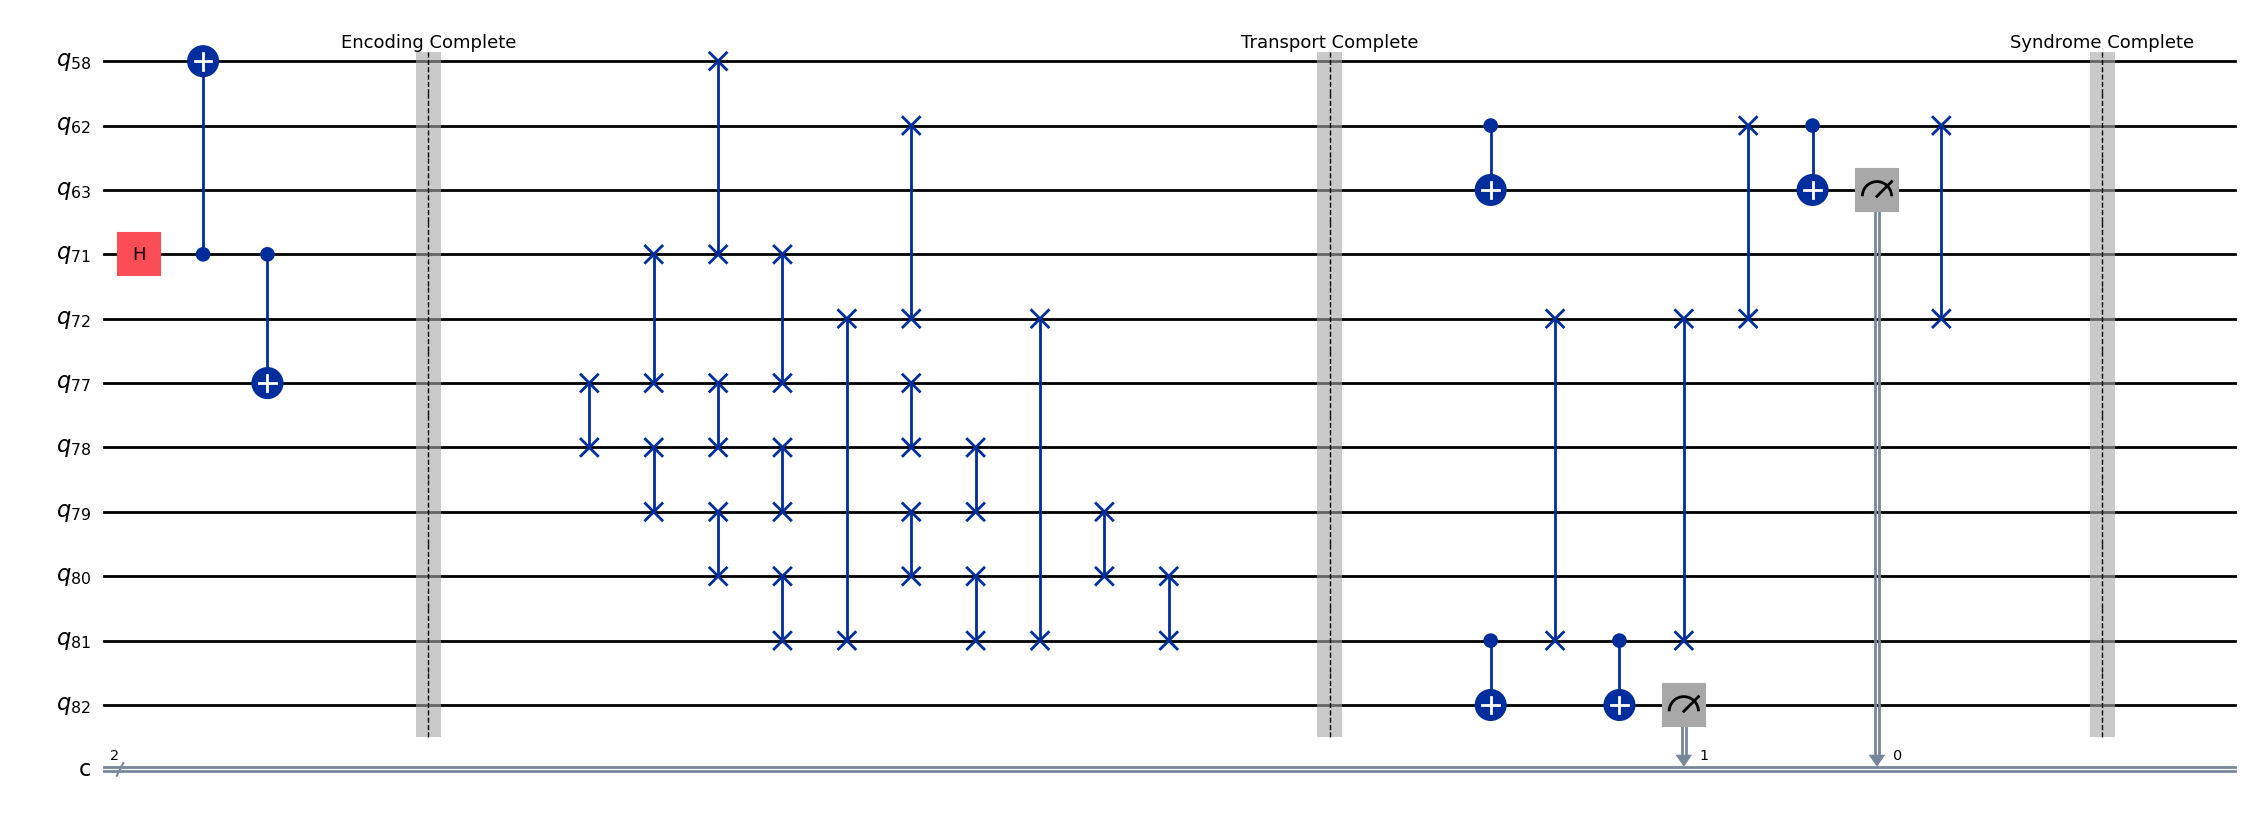

In [8]:
# Draw the circuit (filtered to show only active wires)
qc.draw('mpl', fold=-1, idle_wires=False)

## 4. Transpile and Run Simulation

We transpile the circuit for the FakeBrisbane backend and run it.

In [9]:
# Transpile for the backend
print(">>> Transpiling circuit...")
transpiled_qc = transpile(
    qc, 
    backend, 
    initial_layout=list(range(backend.num_qubits)), 
    optimization_level=1
)

print(f"Transpiled Circuit Depth: {transpiled_qc.depth()}")
print(f"Total SWAPs: {transpiled_qc.count_ops().get('swap', 0)}")
print(f"Total CX gates: {transpiled_qc.count_ops().get('cx', 0)}")

>>> Transpiling circuit...
Transpiled Circuit Depth: 142
Total SWAPs: 0
Total CX gates: 0


In [10]:
# Run simulation
print("\n>>> Running simulation...")
num_shots = 1024

result = backend.run(transpiled_qc, shots=num_shots).result()
counts = result.get_counts()

print(f"\nTotal Shots: {num_shots}")
print(f"Syndrome Counts: {counts}")


>>> Running simulation...

Total Shots: 1024
Syndrome Counts: {'01': 125, '11': 193, '10': 199, '00': 507}


## 5. Analyze Results

The syndrome measurement tells us about errors during transport:

| Syndrome (s1 s0) | Interpretation |
|------------------|----------------|
| 00 | No error detected |
| 01 | Error on qubit 81 (top) |
| 10 | Error on qubit 62 (bottom) |
| 11 | Error on qubit 72 (data/middle) |

In an ideal (noiseless) scenario, we expect all results to be `00`.

=== Syndrome Analysis ===

  Syndrome 00:  507 ( 49.5%) - No error
  Syndrome 01:  125 ( 12.2%) - Error on q81 (top)
  Syndrome 10:  199 ( 19.4%) - Error on q62 (bottom)
  Syndrome 11:  193 ( 18.8%) - Error on q72 (data/middle)

✓ Success Rate (no error detected): 49.5%
✗ Error Rate: 50.5%


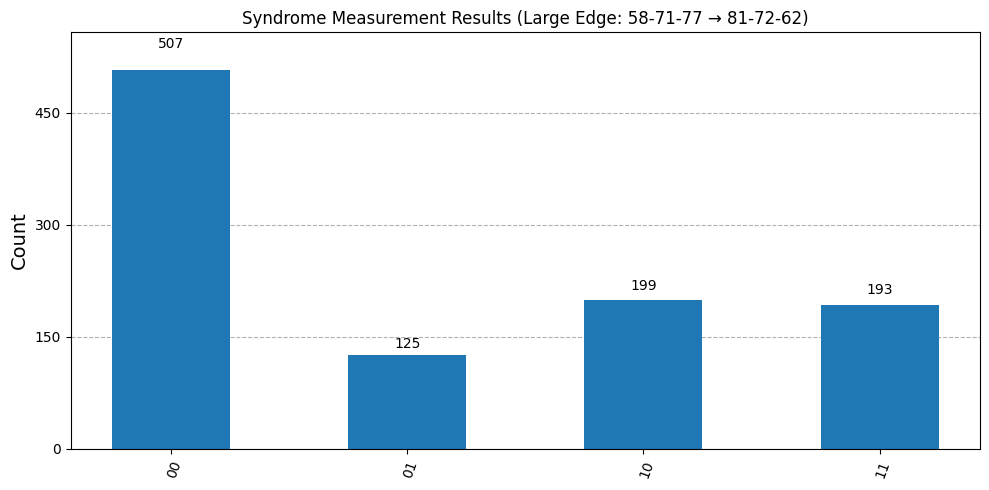

In [11]:
# Analyze syndrome distribution
print("=== Syndrome Analysis ===\n")

# Updated for destination cluster 81-72-62 (Large Edge path)
syndrome_labels = {
    '00': 'No error',
    '01': 'Error on q81 (top)',
    '10': 'Error on q62 (bottom)',
    '11': 'Error on q72 (data/middle)'
}

total_shots = sum(counts.values())

for syndrome, count in sorted(counts.items()):
    percentage = count / total_shots * 100
    label = syndrome_labels.get(syndrome, 'Unknown')
    print(f"  Syndrome {syndrome}: {count:4d} ({percentage:5.1f}%) - {label}")

# Calculate success rate (syndrome 00)
success_count = counts.get('00', 0)
success_rate = success_count / total_shots * 100
print(f"\n✓ Success Rate (no error detected): {success_rate:.1f}%")
print(f"✗ Error Rate: {100 - success_rate:.1f}%")

# Plot histogram
fig, ax = plt.subplots(figsize=(10, 5))
plot_histogram(counts, ax=ax, title="Syndrome Measurement Results (Large Edge: 58-71-77 → 81-72-62)")
plt.tight_layout()
plt.show()

## 6. Analysis: What's Going On?

### Circuit Structure (Large Edge Path)

```
Source (58-71-77)                    Destination (81-72-62)
       58 ─────────────────────────────→ 81  ← Top qubit
       │                                  │
       71 ─────── SWAP chain (via 78-79-80) ─→ 72  ← Data qubit
       │                                  │
       77 ─────────────────────────────→ 62  ← Bottom qubit

Syndrome Ancillas: 82 (measures Z₈₁Z₇₂), 63 (measures Z₇₂Z₆₂)
```

### The [[3,1,1]] Repetition Code

The **[[3,1,1]] code** encodes 1 logical qubit into 3 physical qubits:
- **Encoding**: $|0\rangle_L = |000\rangle$, $|1\rangle_L = |111\rangle$
- **Our state**: $|+\rangle_L = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$ (GHZ-like)

**Stabilizers** (error detection):
- $Z_1 Z_2$ → Parity of qubits 1 & 2
- $Z_2 Z_3$ → Parity of qubits 2 & 3

### The SWAP-Assisted Syndrome Trick

**Problem**: On FakeBrisbane, ancilla 82 connects to qubit 81 but NOT to 72 directly. Similarly, ancilla 63 connects to 62 but NOT to 72.

**Solution**:
1. CNOT from the first data qubit to ancilla (direct connection)
2. SWAP the second data qubit into a position adjacent to the ancilla
3. CNOT the swapped qubit to ancilla
4. Measure the ancilla (gives XOR parity)
5. SWAP back to restore original positions

This is clever because it:
- Avoids routing the ancilla qubit around
- Only temporarily disturbs the data qubit positions
- Works within the Heavy Hex topology constraints

### Why So Many Errors? (Large Edge Has More!)

The **Large Edge** circuit has:
- **18 Transport SWAPs** (each = 3 CNOTs = 54 CX gates) - **50% more than SmallEdge!**
- **4 Syndrome SWAPs** (12 more CX gates)
- **4 Syndrome CNOTs** (4 CX gates)
- **Total**: ~70+ two-qubit gates before transpilation

After transpilation, the circuit depth grows significantly due to:
1. **Direction constraints**: CNOTs may need direction reversal (H gates)
2. **Native gate decomposition**: SWAPs → 3 CX gates each
3. **Connectivity routing**: Additional SWAPs if qubits aren't adjacent

### Expected Results (Worse than SmallEdge)

On a noisy backend like FakeBrisbane:
- **Lower `00` rate than SmallEdge**: More SWAPs = more error accumulation
- **Dominant error syndrome**: Often one path has worse qubits than others
- **Asymmetric distribution**: Different qubit error rates lead to non-uniform syndrome patterns
- **This notebook tests the impact of longer transport distances on error rates**

## 7. Multi-State Syndrome Analysis

Now let's systematically test different initial states for the data qubit and compare syndrome measurements. We'll test:

| State | Preparation | Encoded State |
|-------|-------------|---------------|
| $\|0\rangle$ | None (default) | $\|000\rangle$ |
| $\|1\rangle$ | X gate | $\|111\rangle$ |
| $\|+\rangle$ | H gate | $(\|000\rangle + \|111\rangle)/\sqrt{2}$ |
| $\|-\rangle$ | X + H gates | $(\|000\rangle - \|111\rangle)/\sqrt{2}$ |

For the repetition code [[3,1,1]]:
- **All four logical states** ($\|0\rangle_L$, $\|1\rangle_L$, $\|+\rangle_L$, $\|−\rangle_L$) are $+1$ eigenstates of the $Z$ stabilizers, so the ideal syndrome is always `00`.
- Any non-`00` outcome comes from transport/syndrome errors, not the encoded state.

In [12]:
# Refactored circuit builder function for Large Edge path
def build_311_transport_circuit_large_edge(backend, initial_state='plus', verbose=False):
    """
    Build a [[3,1,1]] encoded qubit transport circuit with syndrome measurement.
    Uses the LARGE EDGE path: Source (58-71-77) → Destination (81-72-62)
    Transport via qubits 78-79-80 (18 SWAPs total).
    
    Parameters:
    -----------
    backend : Backend
        The quantum backend (e.g., FakeBrisbane)
    initial_state : str
        Initial state of data qubit: 'zero', 'one', 'plus', or 'minus'
    verbose : bool
        Print circuit construction details
        
    Returns:
    --------
    QuantumCircuit
        The complete transport + syndrome circuit
    """
    # Qubit assignments (Large Edge path on FakeBrisbane)
    source_qubits = [58, 71, 77]  # [top, data, bottom]
    dest_qubits = [81, 72, 62]    # [top', data', bottom']
    ancilla_qubits = [82, 63]     # Syndrome measurement ancillas
    
    data_qubit = 71  # Center qubit holds the logical data
    
    # Create circuit with 2 classical bits for syndrome
    qc = QuantumCircuit(backend.num_qubits, 2)
    
    # ============================================================
    # STEP 1: ENCODING (at Source: 58, 71, 77)
    # ============================================================
    # Prepare initial state on data qubit
    if initial_state == 'zero':
        pass  # |0⟩ is default
    elif initial_state == 'one':
        qc.x(data_qubit)  # |1⟩
    elif initial_state == 'plus':
        qc.h(data_qubit)  # |+⟩ = (|0⟩ + |1⟩)/√2
    elif initial_state == 'minus':
        qc.x(data_qubit)  # First flip to |1⟩
        qc.h(data_qubit)  # Then H gives |−⟩ = (|0⟩ - |1⟩)/√2
    else:
        raise ValueError(f"Unknown initial_state: {initial_state}")
    
    if verbose:
        print(f"Initial state: |{initial_state}⟩")
    
    # Encode into [[3,1,1]] repetition code
    # |ψ⟩ → |ψψψ⟩ (spread to all 3 qubits)
    qc.cx(data_qubit, 58)  # CNOT to top qubit
    qc.cx(data_qubit, 77)  # CNOT to bottom qubit
    qc.barrier(label="Encode")
    
    # ============================================================
    # STEP 2: TRANSPORT (SWAP Chains) - Large Edge: 18 SWAPs total
    # ============================================================
    # Move 77 → 62 (6 SWAPs) - bottom qubit
    qc.swap(77, 78)
    qc.swap(78, 79)
    qc.swap(79, 80)
    qc.swap(80, 81)
    qc.swap(81, 72)
    qc.swap(72, 62)
    
    # Move 71 → 72 (6 SWAPs) - data qubit
    qc.swap(71, 77)
    qc.swap(77, 78)
    qc.swap(78, 79)
    qc.swap(79, 80)
    qc.swap(80, 81)
    qc.swap(81, 72)
    
    # Move 58 → 81 (6 SWAPs) - top qubit
    qc.swap(58, 71)
    qc.swap(71, 77)
    qc.swap(77, 78)
    qc.swap(78, 79)
    qc.swap(79, 80)
    qc.swap(80, 81)
    
    qc.barrier(label="Transport")
    
    # ============================================================
    # STEP 3: SWAP-ASSISTED SYNDROME MEASUREMENT
    # ============================================================
    # SYNDROME 1: Z₈₁Z₇₂ using ancilla 82
    qc.cx(81, 82)           # Link top qubit to ancilla
    qc.swap(72, 81)         # Bring mid qubit adjacent to ancilla
    qc.cx(81, 82)           # Link mid qubit to ancilla
    qc.measure(82, 1)       # Measure syndrome bit 1
    qc.swap(81, 72)         # Restore positions
    
    # SYNDROME 2: Z₇₂Z₆₂ using ancilla 63
    qc.cx(62, 63)           # Link bot qubit to ancilla
    qc.swap(62, 72)         # Bring mid qubit adjacent to ancilla
    qc.cx(62, 63)           # Link mid qubit to ancilla
    qc.measure(63, 0)       # Measure syndrome bit 0
    qc.swap(72, 62)         # Restore positions
    
    qc.barrier(label="Syndrome")
    
    return qc

# Test the function
print("Circuit builder function defined: build_311_transport_circuit_large_edge()")
print("Large Edge path: 58-71-77 → 81-72-62 (18 SWAPs)")
print("Supported initial states: 'zero', 'one', 'plus', 'minus'")

Circuit builder function defined: build_311_transport_circuit_large_edge()
Large Edge path: 58-71-77 → 81-72-62 (18 SWAPs)
Supported initial states: 'zero', 'one', 'plus', 'minus'


In [13]:
# Run experiments for all 4 initial states
states_to_test = ['zero', 'one', 'plus', 'minus']
state_symbols = {'zero': '|0⟩', 'one': '|1⟩', 'plus': '|+⟩', 'minus': '|−⟩'}
encoded_states = {
    'zero': '|000⟩',
    'one': '|111⟩', 
    'plus': '(|000⟩+|111⟩)/√2',
    'minus': '(|000⟩−|111⟩)/√2'
}

num_shots = 2048
results_by_state = {}

print("=" * 60)
print("Running [[3,1,1]] Transport Experiment (LARGE EDGE PATH)")
print("Source: 58-71-77 → Destination: 81-72-62 (18 SWAPs)")
print("=" * 60)

for state in states_to_test:
    print(f"\n>>> Testing initial state: {state_symbols[state]} → Encoded: {encoded_states[state]}")
    
    # Build circuit using Large Edge function
    qc = build_311_transport_circuit_large_edge(backend, initial_state=state)
    
    # Transpile
    transpiled_qc = transpile(
        qc, 
        backend, 
        initial_layout=list(range(backend.num_qubits)), 
        optimization_level=0
    )
    
    print(f"    Transpiled depth: {transpiled_qc.depth()}, CX gates: {transpiled_qc.count_ops().get('cx', 0)}")
    
    # Run simulation
    result = backend.run(transpiled_qc, shots=num_shots).result()
    counts = result.get_counts()
    
    # Store results
    results_by_state[state] = counts
    
    # Quick summary
    success_rate = counts.get('00', 0) / num_shots * 100
    print(f"    Success rate (syndrome 00): {success_rate:.1f}%")

print("\n" + "=" * 60)
print("All experiments complete!")
print("=" * 60)

Running [[3,1,1]] Transport Experiment (LARGE EDGE PATH)
Source: 58-71-77 → Destination: 81-72-62 (18 SWAPs)

>>> Testing initial state: |0⟩ → Encoded: |000⟩
    Transpiled depth: 209, CX gates: 0
    Success rate (syndrome 00): 47.9%

>>> Testing initial state: |1⟩ → Encoded: |111⟩
    Transpiled depth: 209, CX gates: 0
    Success rate (syndrome 00): 46.0%

>>> Testing initial state: |+⟩ → Encoded: (|000⟩+|111⟩)/√2
    Transpiled depth: 209, CX gates: 0
    Success rate (syndrome 00): 47.0%

>>> Testing initial state: |−⟩ → Encoded: (|000⟩−|111⟩)/√2
    Transpiled depth: 209, CX gates: 0
    Success rate (syndrome 00): 49.5%

All experiments complete!


In [14]:
# Detailed comparison analysis
print("=" * 70)
print("SYNDROME DISTRIBUTION COMPARISON (Large Edge: 81-72-62)")
print("=" * 70)

syndrome_labels = {
    '00': 'No error',
    '01': 'Error on q81',
    '10': 'Error on q62',
    '11': 'Error on q72'
}

# Create comparison table
print(f"\n{'State':<10} {'Encoded':<25} {'00 (OK)':<12} {'01':<12} {'10':<12} {'11':<12}")
print("-" * 83)

for state in states_to_test:
    counts = results_by_state[state]
    total = sum(counts.values())
    
    # Get percentages for each syndrome
    p00 = counts.get('00', 0) / total * 100
    p01 = counts.get('01', 0) / total * 100
    p10 = counts.get('10', 0) / total * 100
    p11 = counts.get('11', 0) / total * 100
    
    print(f"{state_symbols[state]:<10} {encoded_states[state]:<25} {p00:>6.1f}%     {p01:>6.1f}%     {p10:>6.1f}%     {p11:>6.1f}%")

print("-" * 83)

# Calculate averages
avg_00 = np.mean([results_by_state[s].get('00', 0) / sum(results_by_state[s].values()) * 100 for s in states_to_test])
print(f"\n{'Average':<10} {'':<25} {avg_00:>6.1f}%")

print("\n" + "=" * 70)
print("INTERPRETATION (Large Edge Path)")
print("=" * 70)
print("""
• Syndrome '00': No bit-flip error detected during transport
• Syndrome '01': Error detected on top qubit (position 81)  
• Syndrome '10': Error detected on bottom qubit (position 62)
• Syndrome '11': Error detected on middle/data qubit (position 72)

For [[3,1,1]] repetition code:
- All four logical states (|0⟩_L, |1⟩_L, |+⟩_L, |−⟩_L) are +1 eigenstates of the Z stabilizers.
- Any non-`00` outcome comes from transport/syndrome errors, not the encoded state.
- Large Edge path has 18 SWAPs (vs 12 in Small Edge), so expect higher error rates!
""")

SYNDROME DISTRIBUTION COMPARISON (Large Edge: 81-72-62)

State      Encoded                   00 (OK)      01           10           11          
-----------------------------------------------------------------------------------
|0⟩        |000⟩                       47.9%       13.8%       20.8%       17.5%
|1⟩        |111⟩                       46.0%       15.6%       18.7%       19.7%
|+⟩        (|000⟩+|111⟩)/√2            47.0%       15.4%       20.8%       16.8%
|−⟩        (|000⟩−|111⟩)/√2            49.5%       13.9%       19.1%       17.4%
-----------------------------------------------------------------------------------

Average                                47.6%

INTERPRETATION (Large Edge Path)

• Syndrome '00': No bit-flip error detected during transport
• Syndrome '01': Error detected on top qubit (position 81)  
• Syndrome '10': Error detected on bottom qubit (position 62)
• Syndrome '11': Error detected on middle/data qubit (position 72)

For [[3,1,1]] repetition code

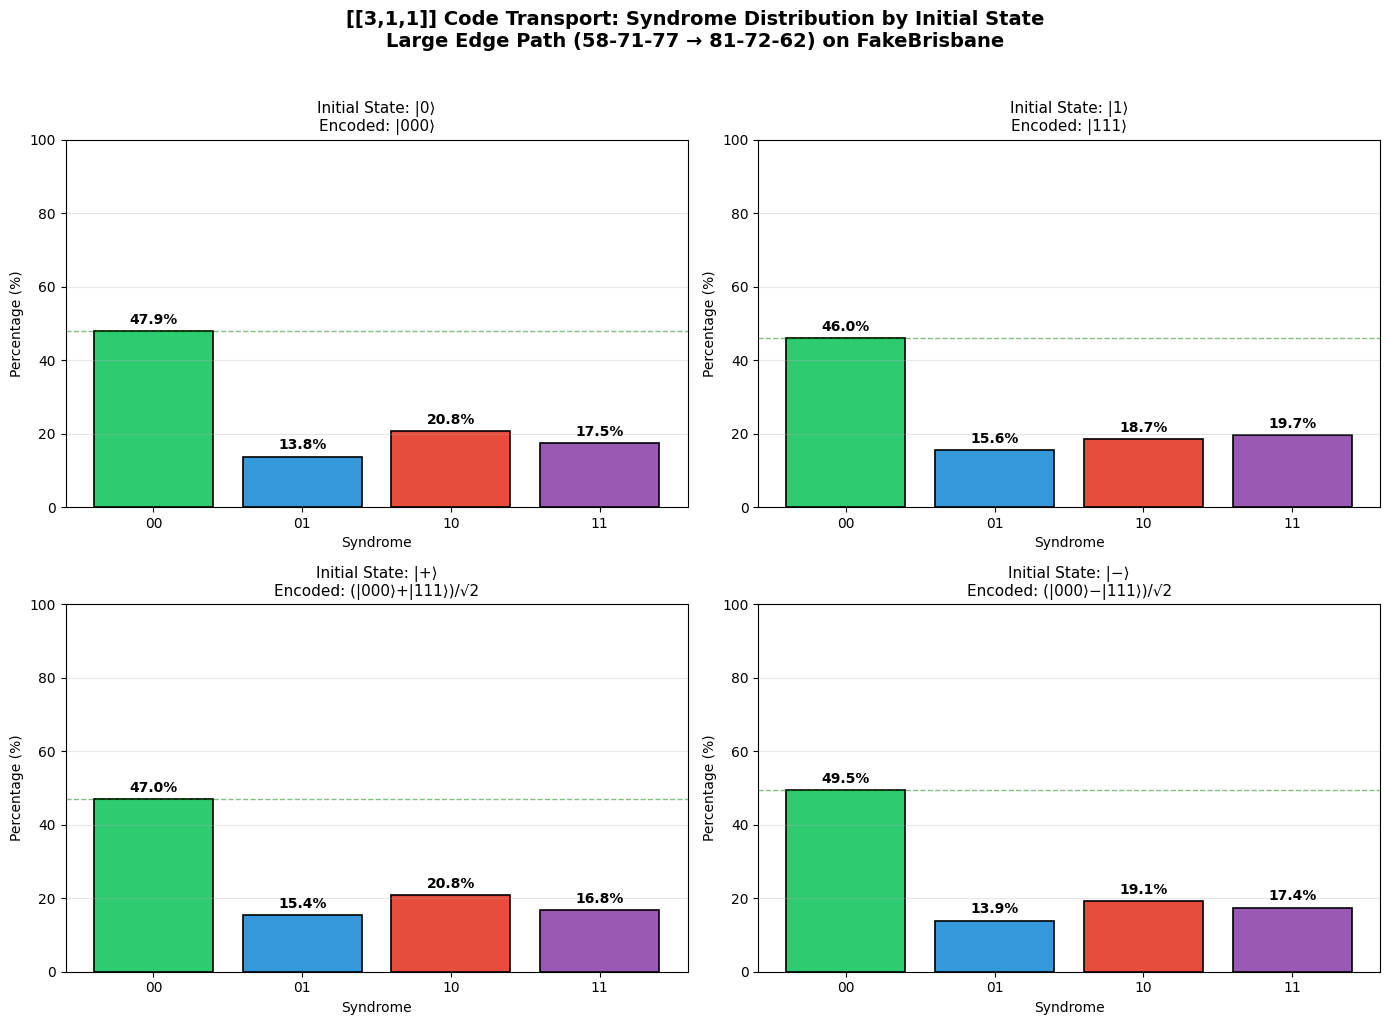


Syndrome Color Legend (Large Edge: dest 81-72-62):
  🟢 00 - No error detected
  🔵 01 - Error on qubit 81 (top)
  🔴 10 - Error on qubit 62 (bottom)
  🟣 11 - Error on qubit 72 (middle/data)


In [15]:
# Visualize syndrome distributions side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

syndrome_order = ['00', '01', '10', '11']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']  # green, blue, red, purple

for idx, state in enumerate(states_to_test):
    ax = axes[idx]
    counts = results_by_state[state]
    total = sum(counts.values())
    
    # Get counts in order
    values = [counts.get(s, 0) for s in syndrome_order]
    percentages = [v / total * 100 for v in values]
    
    bars = ax.bar(syndrome_order, percentages, color=colors, edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        ax.annotate(f'{pct:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f"Initial State: {state_symbols[state]}\nEncoded: {encoded_states[state]}", fontsize=11)
    ax.set_xlabel("Syndrome", fontsize=10)
    ax.set_ylabel("Percentage (%)", fontsize=10)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight success rate
    success_pct = percentages[0]
    ax.axhline(y=success_pct, color='green', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle("[[3,1,1]] Code Transport: Syndrome Distribution by Initial State\nLarge Edge Path (58-71-77 → 81-72-62) on FakeBrisbane", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print legend
print("\nSyndrome Color Legend (Large Edge: dest 81-72-62):")
print("  🟢 00 - No error detected")
print("  🔵 01 - Error on qubit 81 (top)")
print("  🔴 10 - Error on qubit 62 (bottom)")
print("  🟣 11 - Error on qubit 72 (middle/data)")

In [16]:
# Statistical comparison: Are the distributions significantly different?
print("=" * 70)
print("STATISTICAL ANALYSIS: Comparing Syndrome Distributions")
print("Large Edge Path: 58-71-77 → 81-72-62 (18 SWAPs)")
print("=" * 70)

# Calculate chi-square-like metric between distributions
def distribution_distance(counts1, counts2):
    """Calculate total variation distance between two distributions."""
    syndromes = ['00', '01', '10', '11']
    total1 = sum(counts1.values())
    total2 = sum(counts2.values())
    
    tvd = 0
    for s in syndromes:
        p1 = counts1.get(s, 0) / total1
        p2 = counts2.get(s, 0) / total2
        tvd += abs(p1 - p2)
    return tvd / 2  # Total Variation Distance

print("\nTotal Variation Distance (TVD) between distributions:")
print("(TVD = 0 means identical, TVD = 1 means completely different)\n")

# Pairwise comparisons
pairs = [
    ('zero', 'one'),
    ('plus', 'minus'),
    ('zero', 'plus'),
    ('one', 'plus'),
]

for s1, s2 in pairs:
    tvd = distribution_distance(results_by_state[s1], results_by_state[s2])
    print(f"  {state_symbols[s1]} vs {state_symbols[s2]}: TVD = {tvd:.4f}")

# Overall variance analysis
print("\n" + "-" * 70)
print("Success Rate (syndrome 00) Summary - Large Edge Path:")
print("-" * 70)

success_rates = []
for state in states_to_test:
    counts = results_by_state[state]
    total = sum(counts.values())
    rate = counts.get('00', 0) / total * 100
    success_rates.append(rate)
    print(f"  {state_symbols[state]}: {rate:.2f}%")

print(f"\n  Mean:   {np.mean(success_rates):.2f}%")
print(f"  Std:    {np.std(success_rates):.2f}%")
print(f"  Range:  {min(success_rates):.2f}% - {max(success_rates):.2f}%")

print("\n" + "=" * 70)
print("CONCLUSION (Large Edge Path)")
print("=" * 70)
if np.std(success_rates) < 3:
    print("""
✓ The syndrome distributions are very similar across all initial states.
  This confirms that the [[3,1,1]] repetition code syndrome measurement
  is independent of the logical state - it only detects bit-flip errors,
  not the encoded information.
  
  The noise is primarily from the transport SWAPs (18 total) and syndrome
  operations, not from the initial state preparation.
  
  Compare with SmallEdge notebook to see impact of longer transport distance!
""")
else:
    print("""
⚠️ There is noticeable variation in syndrome distributions between states.
   This could indicate:
   - State-dependent noise (SPAM errors)
   - Asymmetric gate errors
   - Leakage or coherent errors that depend on the quantum state
""")

STATISTICAL ANALYSIS: Comparing Syndrome Distributions
Large Edge Path: 58-71-77 → 81-72-62 (18 SWAPs)

Total Variation Distance (TVD) between distributions:
(TVD = 0 means identical, TVD = 1 means completely different)

  |0⟩ vs |1⟩: TVD = 0.0400
  |+⟩ vs |−⟩: TVD = 0.0317
  |0⟩ vs |+⟩: TVD = 0.0171
  |1⟩ vs |+⟩: TVD = 0.0308

----------------------------------------------------------------------
Success Rate (syndrome 00) Summary - Large Edge Path:
----------------------------------------------------------------------
  |0⟩: 47.95%
  |1⟩: 46.04%
  |+⟩: 46.97%
  |−⟩: 49.51%

  Mean:   47.62%
  Std:    1.28%
  Range:  46.04% - 49.51%

CONCLUSION (Large Edge Path)

✓ The syndrome distributions are very similar across all initial states.
  This confirms that the [[3,1,1]] repetition code syndrome measurement
  is independent of the logical state - it only detects bit-flip errors,
  not the encoded information.

  The noise is primarily from the transport SWAPs (18 total) and syndrome
  o